In [2]:
import tensorflow as tf
from tensorflow.keras import layers, Model, Input
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

2025-07-11 23:34:16.971075: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-07-11 23:34:16.971095: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-07-11 23:34:16.971920: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-07-11 23:34:16.977406: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [3]:
def plot_features_subplot(ax, features_2d, labels, technique_name):
    """Helper function to create a scatter plot on a given subplot axis."""
    class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
                   'dog', 'frog', 'horse', 'ship', 'truck']

    sns.scatterplot(x=features_2d[:, 0], y=features_2d[:, 1], hue=labels,
                              palette=sns.color_palette("tab10", n_colors=NUM_CLASSES),
                              legend="full", s=20, ax=ax, alpha=0.7)

    ax.set_title(technique_name)
    ax.set_xlabel("Component 1")
    ax.set_ylabel("Component 2")

    handles, _ = ax.get_legend_handles_labels()
    ax.legend(handles, class_names, title='Class', loc='best', fontsize='small')

In [4]:
NUM_CLASSES = 10
NUM_SAMPLES_FOR_VIZ = 5000

(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# Normalize pixel values to be between 0 and 1
x_train_norm = x_train.astype('float32') / 255.
x_test_norm = x_test.astype('float32') / 255.

# Flatten the labels for plotting
y_train_flat = y_train.flatten()
y_test_flat = y_test.flatten()

# Prepare a subset for visualization to speed up PCA/t-SNE
x_viz = x_test_norm[:NUM_SAMPLES_FOR_VIZ]
y_viz = y_test_flat[:NUM_SAMPLES_FOR_VIZ]

print("CIFAR-10 data loaded and preprocessed.")
print(f"Visualization data shape: {x_viz.shape}")

CIFAR-10 data loaded and preprocessed.
Visualization data shape: (5000, 32, 32, 3)


In [5]:
print("\n--- Starting Experiment 1: Autoencoder ---")

# --- Autoencoder Model Definition (Improved Capacity) ---
input_img_ae = Input(shape=(32, 32, 3))
# Encoder
x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(input_img_ae)
x = layers.MaxPooling2D((2, 2), padding='same')(x)
x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
x = layers.MaxPooling2D((2, 2), padding='same')(x)
x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
x = layers.MaxPooling2D((2, 2), padding='same')(x)
x = layers.Flatten()(x)
encoded_ae = layers.Dense(2)(x)  # 2D latent space

# Decoder
x_dec = layers.Dense(4 * 4 * 128, activation='relu')(encoded_ae)
x_dec = layers.Reshape((4, 4, 128))(x_dec)
x_dec = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x_dec)
x_dec = layers.UpSampling2D((2, 2))(x_dec)
x_dec = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x_dec)
x_dec = layers.UpSampling2D((2, 2))(x_dec)
x_dec = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x_dec)
x_dec = layers.UpSampling2D((2, 2))(x_dec)
decoded_ae = layers.Conv2D(3, (3, 3), activation='sigmoid', padding='same')(x_dec)

autoencoder = Model(input_img_ae, decoded_ae)
encoder_ae = Model(input_img_ae, encoded_ae)



--- Starting Experiment 1: Autoencoder ---


2025-07-11 23:34:20.247735: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-07-11 23:34:20.296137: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-07-11 23:34:20.296336: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-

In [6]:
# --- Compile and Train Autoencoder ---
print("\nTraining the Autoencoder...")
autoencoder.compile(optimizer='adam', loss='mean_squared_error')
autoencoder.fit(
    x_train_norm, x_train_norm,
    epochs=50,
    batch_size=128,
    shuffle=True,
    validation_data=(x_test_norm, x_test_norm),
    verbose=1
)


Training the Autoencoder...
Epoch 1/50


2025-07-11 23:34:23.926595: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8907
2025-07-11 23:34:25.050506: I external/local_xla/xla/service/service.cc:168] XLA service 0x738b32f55450 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-07-11 23:34:25.050527: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA GeForce GTX 1070, Compute Capability 6.1
2025-07-11 23:34:25.055361: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1752255265.123978  176664 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


391/391 [==============================] - 11s 17ms/step - loss: 0.0397 - val_loss: 0.0369
Epoch 2/50
391/391 [==============================] - 5s 13ms/step - loss: 0.0368 - val_loss: 0.0368
Epoch 3/50
391/391 [==============================] - 5s 13ms/step - loss: 0.0367 - val_loss: 0.0368
Epoch 4/50
391/391 [==============================] - 5s 13ms/step - loss: 0.0366 - val_loss: 0.0365
Epoch 5/50
391/391 [==============================] - 5s 13ms/step - loss: 0.0365 - val_loss: 0.0365
Epoch 6/50
391/391 [==============================] - 5s 13ms/step - loss: 0.0365 - val_loss: 0.0367
Epoch 7/50
391/391 [==============================] - 5s 13ms/step - loss: 0.0365 - val_loss: 0.0364
Epoch 8/50
391/391 [==============================] - 5s 13ms/step - loss: 0.0364 - val_loss: 0.0365
Epoch 9/50
391/391 [==============================] - 5s 13ms/step - loss: 0.0364 - val_loss: 0.0363
Epoch 10/50
391/391 [==============================] - 5s 13ms/step - loss: 0.0363 - val_loss: 0.0363

In [7]:
# --- Generate Features with Autoencoder ---
print("\nExtracting 2D features using the trained autoencoder...")
features_ae_2d = encoder_ae.predict(x_viz, verbose=1)
print(f"Shape of autoencoder features: {features_ae_2d.shape}")



Extracting 2D features using the trained autoencoder...
157/157 [==============================] - 1s 2ms/step
Shape of autoencoder features: (5000, 2)


In [8]:
print("\n--- Starting Experiment 2: Pre-trained CNN (MobileNetV2) ---")

input_tensor_tl = Input(shape=(32, 32, 3))
base_model = MobileNetV2(weights='imagenet', include_top=False, input_tensor=input_tensor_tl)

# --- Prepare the Model for Fine-Tuning ---
# Start by freezing all layers in the base model.
base_model.trainable = False

# Unfreeze the top 10 layers of the model to allow them to be trained.
# This adapts the high-level features of MobileNetV2 to the specifics of CIFAR-10.
for layer in base_model.layers[-10:]:
    layer.trainable = True

# --- Build the New Model for Fine-Tuning ---
# Add custom layers on top of the base model for our specific classification task.
x_tl = base_model.output
x_tl = GlobalAveragePooling2D()(x_tl)  # Pool the features to a single vector per image.

# This layer will be used to extract features after the model is trained.
feature_layer = x_tl
# Add the final classification layer.
predictions = Dense(NUM_CLASSES, activation='softmax')(feature_layer)

# Create the complete model to be fine-tuned.
model_for_finetuning = Model(inputs=base_model.input, outputs=predictions)

# --- Compile the Model ---
# A low learning rate is crucial for fine-tuning to avoid corrupting the pre-trained weights.
print("Compiling model for fine-tuning...")
model_for_finetuning.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
                             loss='sparse_categorical_crossentropy',
                             metrics=['accuracy'])

# --- Fine-Tune the Model ---
print("\nFine-tuning the top layers of MobileNetV2 on CIFAR-10...")
model_for_finetuning.fit(
    x_train_norm, y_train,
    epochs=50,
    batch_size=64,
    validation_data=(x_test_norm, y_test),
    verbose=1
)

# --- Create Feature Extractor from the Fine-Tuned Model ---
# This extractor uses the updated weights from the fine-tuning process
feature_extractor_tl = Model(inputs=base_model.input, outputs=feature_layer)

print("\nExtracting high-dimensional features using the fine-tuned MobileNetV2...")
features_high_dim = feature_extractor_tl.predict(x_viz, verbose=1)
print(f"Shape of high-dimensional features: {features_high_dim.shape}")

# --- Reduce Dimensions using PCA ---
print("Applying PCA to reduce features to 2D...")
pca = PCA(n_components=2, random_state=42)
features_pca_2d = pca.fit_transform(features_high_dim)
print(f"Shape of PCA features: {features_pca_2d.shape}")

# --- Reduce Dimensions using t-SNE ---
print("Applying t-SNE to reduce features to 2D... (This may take a minute)")
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
features_tsne_2d = tsne.fit_transform(features_high_dim)
print(f"Shape of t-SNE features: {features_tsne_2d.shape}")


--- Starting Experiment 2: Pre-trained CNN (MobileNetV2) ---
Compiling model for fine-tuning...

Fine-tuning the top layers of MobileNetV2 on CIFAR-10...
Epoch 1/50
782/782 [==============================] - 16s 15ms/step - loss: 1.6884 - accuracy: 0.4354 - val_loss: 2.0744 - val_accuracy: 0.2579
Epoch 2/50
782/782 [==============================] - 10s 13ms/step - loss: 1.2780 - accuracy: 0.5573 - val_loss: 2.6932 - val_accuracy: 0.2664
Epoch 3/50
782/782 [==============================] - 10s 13ms/step - loss: 1.1342 - accuracy: 0.6028 - val_loss: 1.8776 - val_accuracy: 0.3910
Epoch 4/50
782/782 [==============================] - 11s 14ms/step - loss: 1.0315 - accuracy: 0.6384 - val_loss: 1.5157 - val_accuracy: 0.4723
Epoch 5/50
782/782 [==============================] - 10s 13ms/step - loss: 0.9527 - accuracy: 0.6666 - val_loss: 1.4535 - val_accuracy: 0.5089
Epoch 6/50
782/782 [==============================] - 9s 12ms/step - loss: 0.8774 - accuracy: 0.6970 - val_loss: 1.3354 - val

/home/cse/miniforge3/lib/python3.10/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


Shape of t-SNE features: (5000, 2)


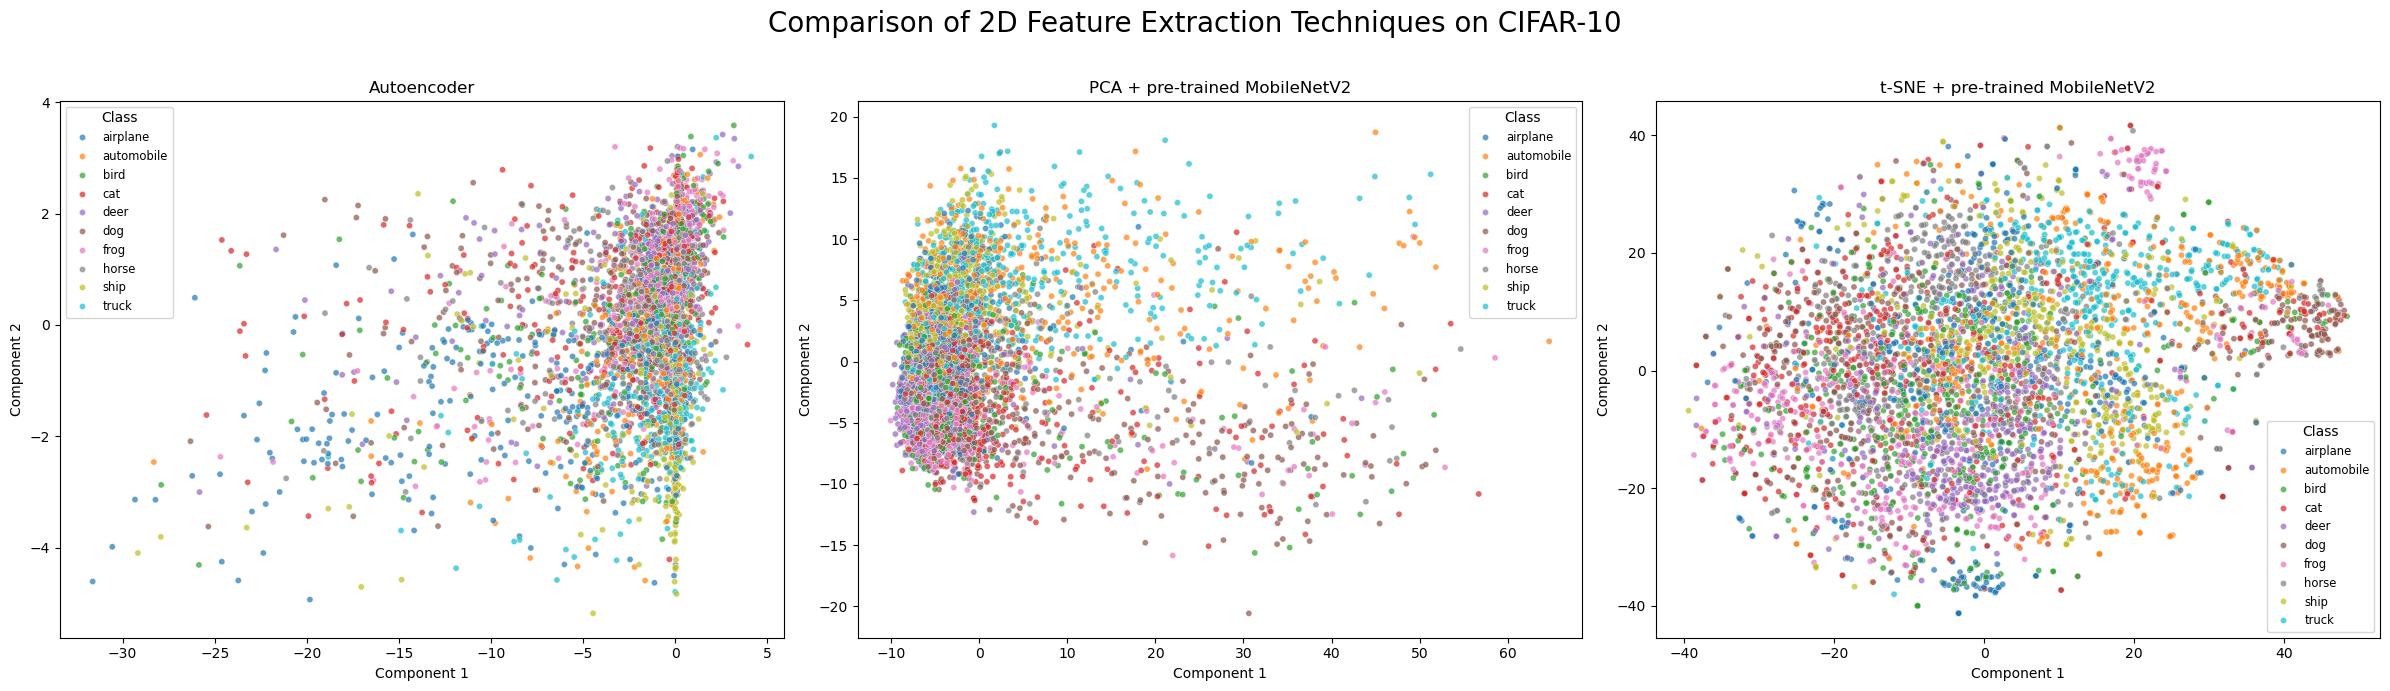

In [9]:
fig_comp, axes_comp = plt.subplots(1, 3, figsize=(24, 7))
fig_comp.suptitle("Comparison of 2D Feature Extraction Techniques on CIFAR-10", fontsize=20)

# Plot 1: Autoencoder
plot_features_subplot(axes_comp[0], features_ae_2d, y_viz, "Autoencoder")

# Plot 2: PCA
plot_features_subplot(axes_comp[1], features_pca_2d, y_viz, "PCA + pre-trained MobileNetV2")

# Plot 3: t-SNE
plot_features_subplot(axes_comp[2], features_tsne_2d, y_viz, "t-SNE + pre-trained MobileNetV2")

# Show the plots
plt.tight_layout()

plt.subplots_adjust(top=0.85)  # Adjust the top to fit the suptitle


plt.show()
